# Project Logo Classification using Deep Learning

## Import libraries and set random seed

This cell imports all the required libraries for data handling, preprocessing, visualization, model building, evaluation and saving results. 
A fixed random seed is also set to make the experiments more reproducible.

In [ ]:
import os
import shutil
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageOps, ImageFilter

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.layers import Dense, Activation, Dropout, GlobalAveragePooling2D

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## Project paths and creation of working folders

This cell defines the paths to the dataset folder, image directory, annotation files, and output folders. It also creates the working directories used to store cropped images, train/validation/test folders, saved models and prediction files.

In [142]:
base_dir = Path(os.getcwd())
dataset_root = base_dir / "flickr_logos_27_dataset"

image_dir = dataset_root / "flickr_logos_27_dataset_images"

train_annotation_file = dataset_root / "flickr_logos_27_dataset_training_set_annotation.txt"
test_annotation_file = dataset_root / "flickr_logos_27_dataset_query_set_annotation.txt"

work_dir = base_dir / "logo_classification_work"
cropped_dir = work_dir / "cropped_train_images"
dataset_dir = work_dir / "dataset"
model_dir = work_dir / "models"

for folder in [work_dir, cropped_dir, dataset_dir, model_dir]:
    folder.mkdir(parents=True, exist_ok=True)

print("Dataset root exists:", dataset_root.exists())
print("Images dir exists:", image_dir.exists())
print("Train annotation exists:", train_annotation_file.exists())
print("Test annotation exists:", test_annotation_file.exists())

Dataset root exists: True
Images dir exists: True
Train annotation exists: True
Test annotation exists: True


## Load training and query annotation files

This cell loads the annotation files into pandas DataFrames. The training annotations include filename, label, subset and bounding box coordinates, while the query annotations include filename and label only.

In [143]:
# Load training annotations
train_images = pd.read_csv(
    train_annotation_file,
    sep=r"\s+",
    usecols=[0, 1, 2, 3, 4, 5, 6],
    header=None,
    names=["file_name", "label", "subset", "x1", "y1", "x2", "y2"],
    engine="python"
)

train_images.head()

# Load query annotations
test_images = pd.read_csv(
    test_annotation_file,
    sep=r"\s+|\t+",
    usecols=[0, 1],
    header=None,
    names=["file_name", "label"],
    engine="python"
)

test_images.head()
        

,file_name,label
0,2403695909.jpg,Adidas
1,2912587920.jpg,Adidas
2,3441398196.jpg,Adidas
3,4605630935.jpg,Adidas
4,4606245138.jpg,Adidas


## Clean and validate annotation data

This cell converts numeric columns to the correct format, removes invalid or duplicate rows, and standardizes the filename and label columns as strings.

In [144]:
# Clean training data
for col in ["subset", "x1", "y1", "x2", "y2"]:
    train_images[col] = pd.to_numeric(train_images[col], errors="coerce")

train_images = train_images.dropna(subset=["file_name", "label", "subset", "x1", "y1", "x2", "y2"]).copy()

train_images["file_name"] = train_images["file_name"].astype(str)
train_images["label"] = train_images["label"].astype(str)
train_images["subset"] = train_images["subset"].astype(int)

for col in ["x1", "y1", "x2", "y2"]:
    train_images[col] = train_images[col].astype(int)

# Clean test data
test_images = test_images.dropna(subset=["file_name", "label"]).copy()
test_images["file_name"] = test_images["file_name"].astype(str)
test_images["label"] = test_images["label"].astype(str)

# Remove duplicate entries
train_images = train_images.drop_duplicates().reset_index(drop=True)
test_images = test_images.drop_duplicates().reset_index(drop=True)

print("Train annotations:", train_images.shape)
print("Test annotations:", test_images.shape)
print("Unique train labels:", len(train_images['label'].unique()))
print("Unique test labels:", len(test_images['label'].unique()))

# Check if image files exist
train_images["exists"] = train_images["file_name"].apply(lambda x: (image_dir / x).exists())
test_images["exists"] = test_images["file_name"].apply(lambda x: (image_dir / x).exists())

print("Missing train images:", (~train_images["exists"]).sum())
print("Missing test images:", (~test_images["exists"]).sum())

train_images = train_images[train_images["exists"]].drop(columns=["exists"]).reset_index(drop=True)
test_images = test_images[test_images["exists"]].drop(columns=["exists"]).reset_index(drop=True)

print("Remaining train rows:", len(train_images))
print("Remaining test rows:", len(test_images))

Train annotations: (4536, 7)
Test annotations: (270, 2)
Unique train labels: 27
Unique test labels: 28
Missing train images: 0
Missing test images: 0
Remaining train rows: 4536
Remaining test rows: 270


## Display sample images from the dataset

This cell visualizes a sample of images from the dataset together with their labels. The purpose is to inspect the raw data and confirm that the image files are being loaded correctly before preprocessing begins.

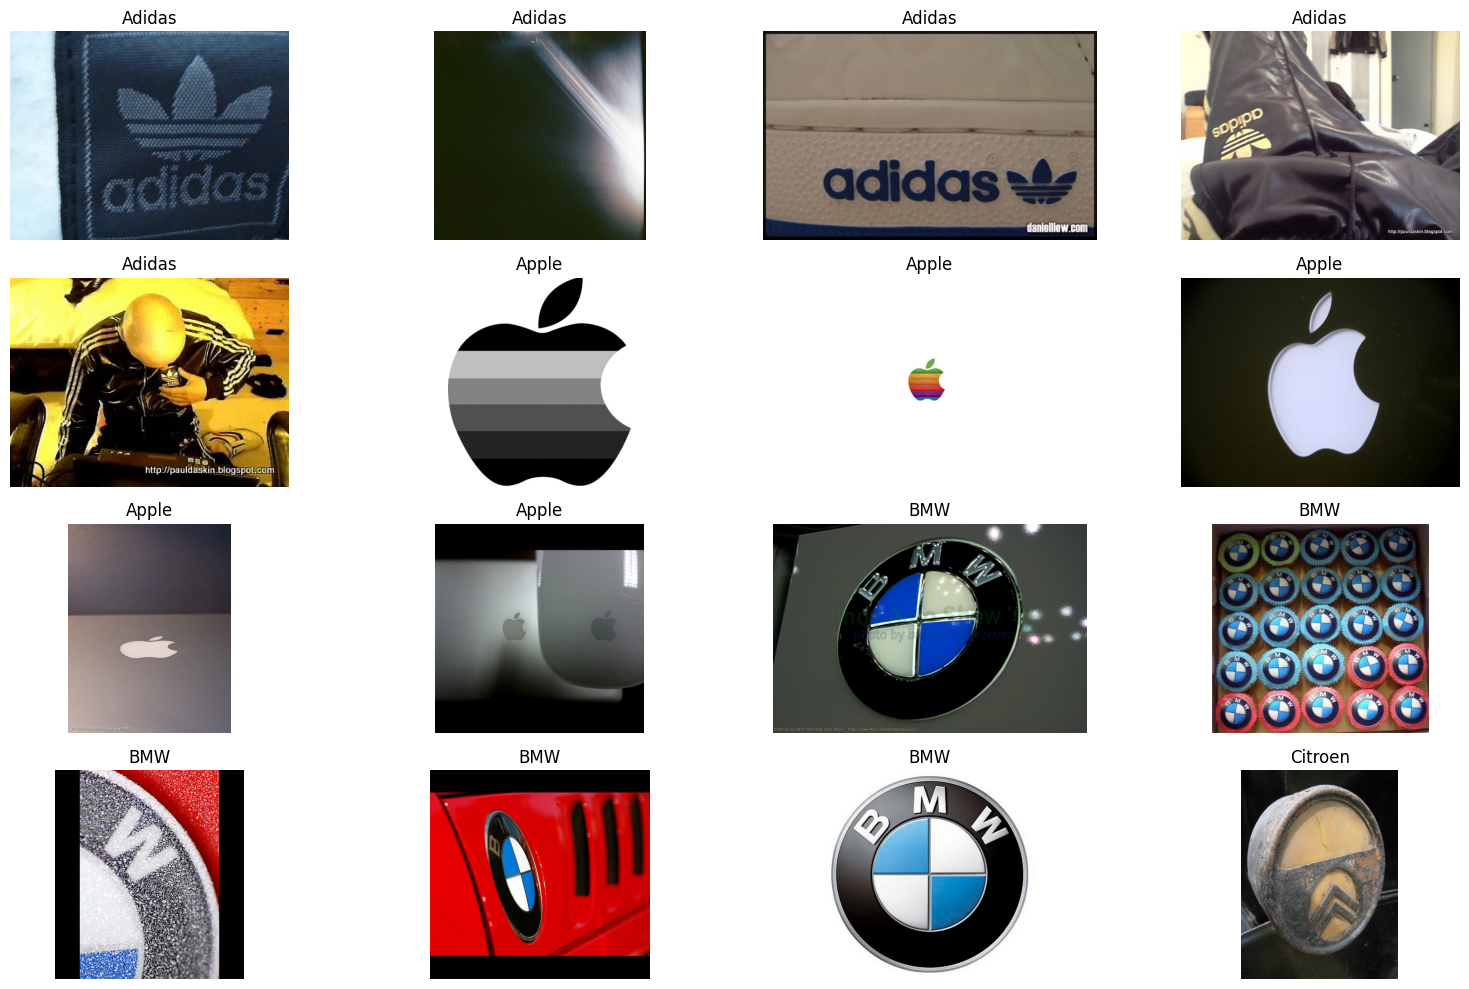

In [ ]:
# Display a sample of dataset images to inspect labels and verify image loading
plt.figure(figsize=(16, 10))

sample_n = min(16, len(test_images))
for idx in range(sample_n):
    ax = plt.subplot(4, 4, idx + 1)
    img_path = image_dir / test_images.loc[idx, "file_name"]
    plt.imshow(Image.open(img_path).convert("RGB"))
    plt.title(test_images.loc[idx, "label"])
    plt.axis("off")

plt.tight_layout()
plt.show()

## Crop logo regions using bounding box annotations

This cell defines a safe cropping function and uses the bounding box coordinates from the training annotation file to extract only the logo area from each image. The cropped images are saved into class-based folders and recorded in a new DataFrame for later use.

In [ ]:
# Function that safely crops an image using bounding box coordinates.
def safe_crop(img, x1, y1, x2, y2):
    w, h = img.size
    
    x1 = max(0, min(int(x1), w - 1))
    y1 = max(0, min(int(y1), h - 1))
    x2 = max(0, min(int(x2), w))
    y2 = max(0, min(int(y2), h))

    if x2 <= x1 or y2 <= y1:
        return None
    
    return img.crop((x1, y1, x2, y2))

# Cleanup if cropped_dir already exists
if cropped_dir.exists():
    shutil.rmtree(cropped_dir)
cropped_dir.mkdir(parents=True, exist_ok=True)

cropped_records = []

for idx, row in train_images.iterrows():
    img_path = image_dir / str(row["file_name"])
    try:
        img = Image.open(img_path).convert("RGB")
        cropped_img = safe_crop(img, row["x1"], row["y1"], row["x2"], row["y2"])
        
        if cropped_img is None:
            continue
        
        class_dir = cropped_dir / str(row["label"])
        class_dir.mkdir(parents=True, exist_ok=True)
        
        crop_filename = f"{Path(str(row['file_name'])).stem}_subset{row['subset']}_{idx}.jpg"
        crop_path = class_dir / crop_filename
        cropped_img.save(crop_path)
        
        cropped_records.append({
            "crop_path": str(crop_path),
            "crop_file_name": crop_filename,
            "label": str(row["label"]),
            "original_file_name": str(row["file_name"]),
            "subset": str(row["subset"])
        })
    except Exception as e:
        print(f"Skipping {row['file_name']} error: {e}")

cropped_df = pd.DataFrame(cropped_records)
print("Total cropped samples:", len(cropped_df))
print(cropped_df.head())
print(cropped_df.columns)
print(cropped_df.shape)


Total cropped samples: 4531
                                           crop_path  \
0  c:\Users\xriso\Desktop\Project Logo Classifica...   
1  c:\Users\xriso\Desktop\Project Logo Classifica...   
2  c:\Users\xriso\Desktop\Project Logo Classifica...   
3  c:\Users\xriso\Desktop\Project Logo Classifica...   
4  c:\Users\xriso\Desktop\Project Logo Classifica...   

             crop_file_name   label original_file_name subset  
0   144503924_subset1_0.jpg  Adidas      144503924.jpg      1  
1  2451569770_subset1_1.jpg  Adidas     2451569770.jpg      1  
2   390321909_subset1_2.jpg  Adidas      390321909.jpg      1  
3  4761260517_subset1_3.jpg  Adidas     4761260517.jpg      1  
4  4763210295_subset1_4.jpg  Adidas     4763210295.jpg      1  
Index(['crop_path', 'crop_file_name', 'label', 'original_file_name', 'subset'], dtype='object')
(4531, 5)


## Visualize cropped logos and class distribution

This cell displays examples of the cropped logo images and then plots the number of cropped samples per class. This helps verify that preprocessing worked correctly and also gives an overview of how balanced the dataset is across logo categories.

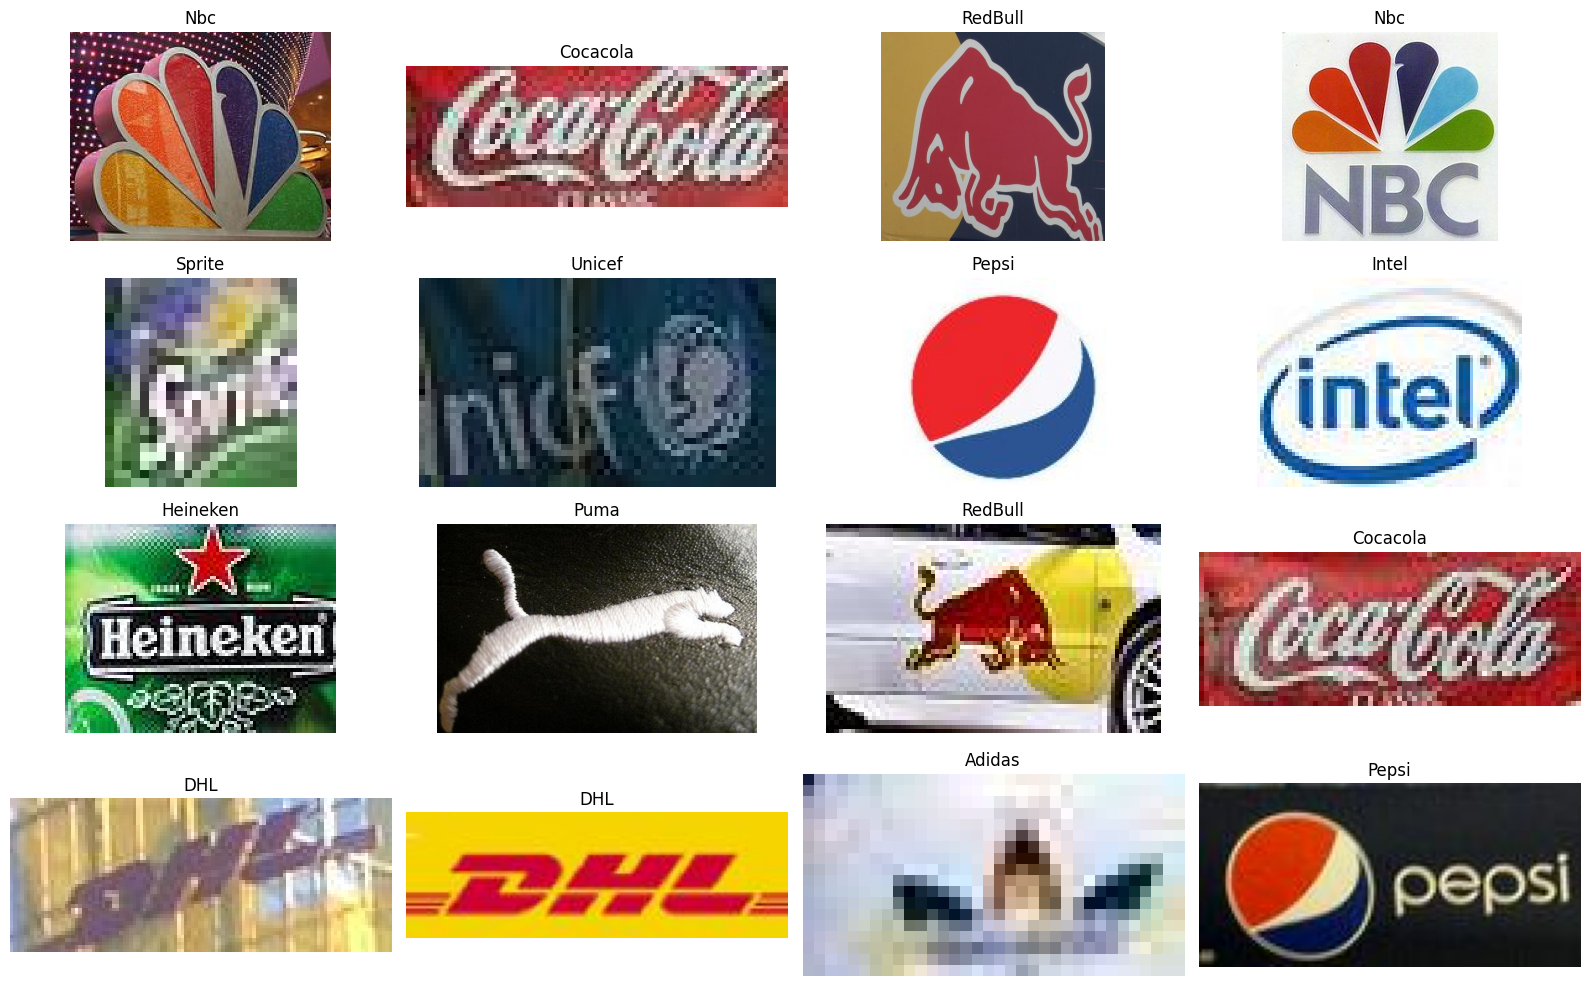

                                           crop_path  \
0  c:\Users\xriso\Desktop\Project Logo Classifica...   
1  c:\Users\xriso\Desktop\Project Logo Classifica...   
2  c:\Users\xriso\Desktop\Project Logo Classifica...   
3  c:\Users\xriso\Desktop\Project Logo Classifica...   
4  c:\Users\xriso\Desktop\Project Logo Classifica...   

             crop_file_name   label original_file_name subset  
0   144503924_subset1_0.jpg  Adidas      144503924.jpg      1  
1  2451569770_subset1_1.jpg  Adidas     2451569770.jpg      1  
2   390321909_subset1_2.jpg  Adidas      390321909.jpg      1  
3  4761260517_subset1_3.jpg  Adidas     4761260517.jpg      1  
4  4763210295_subset1_4.jpg  Adidas     4763210295.jpg      1  
Index(['crop_path', 'crop_file_name', 'label', 'original_file_name', 'subset'], dtype='object')
(4531, 5)


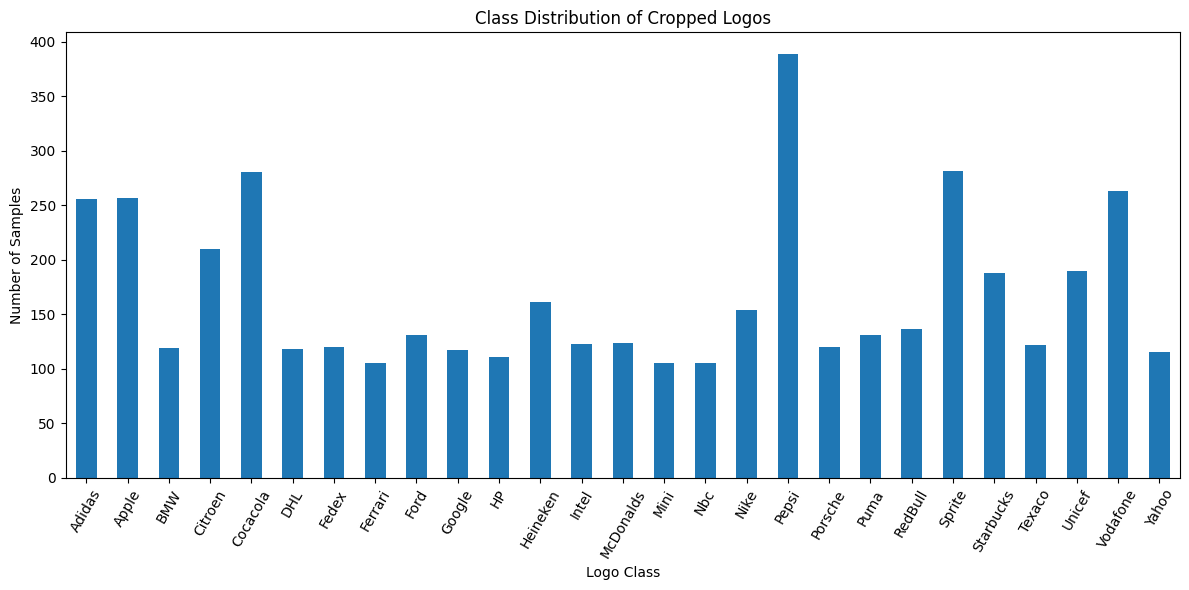

In [ ]:
# Display random cropped logo images and plot the class distribution after preprocessing
plt.figure(figsize=(16, 10))

sample_df = cropped_df.sample(min(16, len(cropped_df)), random_state=SEED).reset_index(drop=True)

for idx in range(len(sample_df)):
    ax = plt.subplot(4, 4, idx + 1)
    img_path = sample_df.loc[idx, "crop_path"]
    plt.imshow(Image.open(img_path).convert("RGB"))
    plt.title(sample_df.loc[idx, "label"])
    plt.axis("off")
    
plt.tight_layout()
plt.show()

# Class distribution
print(cropped_df.head())
print(cropped_df.columns)
print(cropped_df.shape)
plt.figure(figsize=(12, 6))
cropped_df["label"].value_counts().sort_index().plot(kind="bar")
plt.title("Class Distribution of Cropped Logos")
plt.xlabel("Logo Class")
plt.ylabel("Number of Samples")
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

## Create custom training and validation splits

This cell creates the required custom training and validation sets using stratified sampling. Stratification preserves the class distribution across both splits.

In [ ]:
# Create custom train and validation splits using stratified sampling
train_df, val_df = train_test_split(
    cropped_df, 
    test_size=0.2,
    random_state=SEED,
    stratify=cropped_df["label"]
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print("Train set:", train_df.shape)
print("Validation set:", val_df.shape)

Train set: (3624, 5)
Validation set: (907, 5)


## Build directory-based datasets for training, validation, and testing

This cell creates the folder structure expected by `flow_from_directory()` and copies images into class-specific directories. The cropped training images are used for the train and validation sets, while the query images are copied into the test folder for final prediction.

In [ ]:
# Create dataset directories
train_dir = dataset_dir / "train"
val_dir = dataset_dir / "val"
test_dir = dataset_dir / "test"

# Clean old directories if they exist
for folder in [train_dir, val_dir, test_dir]:
    if folder.exists():
        shutil.rmtree(folder)
    folder.mkdir(parents=True, exist_ok=True)

# Copy images into class-based folders so they can be loaded with flow_from_directory()
def copy_classifications_images(df, target_dir, source_col="crop_path", label_col="label"):
    for _, row in df.iterrows():
        class_dir = target_dir / row[label_col]
        class_dir.mkdir(parents=True, exist_ok=True)
        src = Path(row[source_col])
        dst = class_dir / src.name
        shutil.copy(src, dst)

# Copy train and validation images
copy_classifications_images(train_df, train_dir)
copy_classifications_images(val_df, val_dir)

# Copy query images for testing
for _, row in test_images.iterrows():
    src = image_dir / row["file_name"]
    class_dir = test_dir / row["label"]
    class_dir.mkdir(parents=True, exist_ok=True)
    dst = class_dir / row["file_name"]
    shutil.copy(src, dst)

print("Train dir ready:", train_dir)
print("Val dir ready:", val_dir)
print("Test dir ready:", test_dir)

Train dir ready: c:\Users\xriso\Desktop\Project Logo Classification Code\logo_classification_work\dataset\train
Val dir ready: c:\Users\xriso\Desktop\Project Logo Classification Code\logo_classification_work\dataset\val
Test dir ready: c:\Users\xriso\Desktop\Project Logo Classification Code\logo_classification_work\dataset\test


## Create image generators and apply data augmentation

This cell defines the image preprocessing pipeline. The training generator applies augmentation such as rotation, shift, zoom, shear, and flipping in order to improve generalization, while the validation and test generators only rescale the images.

In [ ]:
# Create data generators: augmented training data and rescaled validation/test data
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.15,
    shear_range=0.10,
    horizontal_flip=True,
    fill_mode="nearest"
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=SEED
)

val_data = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_data = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

print("Number of classes:", train_data.num_classes)
print("Class indices:", train_data.class_indices)

Found 3624 images belonging to 27 classes.
Found 907 images belonging to 27 classes.
Found 270 images belonging to 28 classes.
Number of classes: 27
Class indices: {'Adidas': 0, 'Apple': 1, 'BMW': 2, 'Citroen': 3, 'Cocacola': 4, 'DHL': 5, 'Fedex': 6, 'Ferrari': 7, 'Ford': 8, 'Google': 9, 'HP': 10, 'Heineken': 11, 'Intel': 12, 'McDonalds': 13, 'Mini': 14, 'Nbc': 15, 'Nike': 16, 'Pepsi': 17, 'Porsche': 18, 'Puma': 19, 'RedBull': 20, 'Sprite': 21, 'Starbucks': 22, 'Texaco': 23, 'Unicef': 24, 'Vodafone': 25, 'Yahoo': 26}


## Display augmented training images

This cell visualizes a batch of augmented training images produced by the data generator.

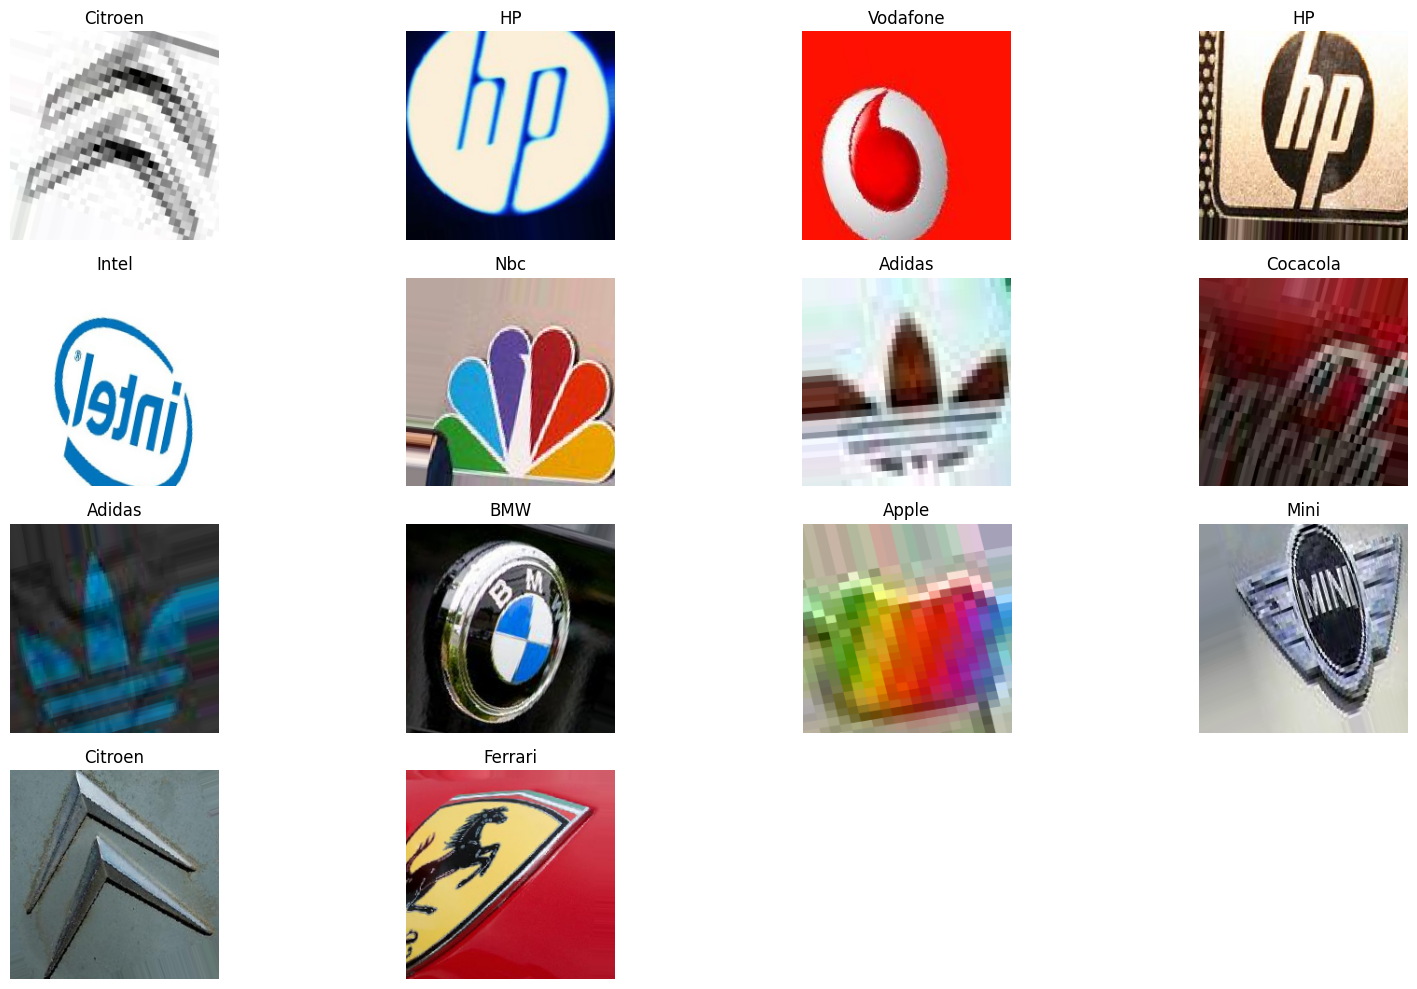

In [151]:
# Display some augmented training images
images, labels = next(train_data)

plt.figure(figsize=(16, 10))
for idx in range(min(14, len(images))):
    ax = plt.subplot(4, 4, idx + 1)
    plt.imshow(images[idx])
    plt.title(list(train_data.class_indices.keys())[np.argmax(labels[idx])])
    plt.axis("off")

plt.tight_layout()
plt.show()

## Build the baseline CNN model

This cell defines a basic convolutional neural network from scratch.

In [ ]:
# Build a baseline CNN from scratch for comparison with transfer learning
num_classes = train_data.num_classes
base_model = keras.Sequential([
    layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(256, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    
    layers.Flatten(),
    layers.Dense(512, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation="softmax")
])

base_model.compile(
    optimizer = "adam",
    loss = "categorical_crossentropy",
    metrics = ["accuracy"]
)

base_model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 512)            │    18,874,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 27)             │        13,851 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,277,147 (73.54 MB)

 Trainable params: 19,277,147 (73.54 MB)

 Non-trainable params: 0 (0.00 B)

## Train the baseline CNN model

This cell trains the basic CNN using the training data and evaluates it on the validation set after each epoch.

In [ ]:
# Train the baseline CNN and save the best checkpoint based on validation accuracy
base_model_path = model_dir / "basic_cnn_best.keras"

callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2),
    ModelCheckpoint(base_model_path, monitor="val_accuracy", save_best_only=True)
]

history = base_model.fit(
    train_data,
    epochs=10,
    validation_data=val_data,
    callbacks=callbacks
)

Epoch 1/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 34s 297ms/step - accuracy: 0.2235 - loss: 2.7352 - val_accuracy: 0.4609 - val_loss: 1.8325 - learning_rate: 0.0010
Epoch 2/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 27s 237ms/step - accuracy: 0.4556 - loss: 1.8847 - val_accuracy: 0.6869 - val_loss: 1.1105 - learning_rate: 0.0010
Epoch 3/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 28s 246ms/step - accuracy: 0.6068 - loss: 1.3567 - val_accuracy: 0.7817 - val_loss: 0.8076 - learning_rate: 0.0010
Epoch 4/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 29s 255ms/step - accuracy: 0.6760 - loss: 1.0786 - val_accuracy: 0.8071 - val_loss: 0.6901 - learning_rate: 0.0010
Epoch 5/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 29s 256ms/step - accuracy: 0.7373 - loss: 0.9012 - val_accuracy: 0.8313 - val_loss: 0.5521 - learning_rate: 0.0010
Epoch 6/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 30s 260ms/step - accuracy: 0.7804 - loss: 0.7583 - val_accuracy: 0.8798 - val_loss: 0.4476 - learning_rate: 0.0010
Epoch 7/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 29s 252ms/step - accuracy: 0.8

## Build the transfer learning model

This cell defines a transfer learning model using MobileNetV2 pretrained on ImageNet. The convolutional base is initially frozen, and only the classification head is trained.

In [ ]:
# Build a transfer learning classifier using MobileNetV2
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

transfer_model = keras.Sequential([
    layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.5),
    Dense(256, activation="relu"),
    Dropout(0.5),
    Dense(num_classes, activation="softmax")
])

transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

transfer_model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 27)             │         6,939 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,592,859 (9.89 MB)

 Trainable params: 334,875 (1.28 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Train the transfer learning model

This cell trains the transfer learning model with the pretrained backbone frozen.

In [155]:
# Train the transfer learning model
transfer_model_path = model_dir / "transfer_learning_best.keras"

callbacks_transfer = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2),
    ModelCheckpoint(transfer_model_path, monitor="val_accuracy", save_best_only=True)
]

history_transfer = transfer_model.fit(
    train_data,
    epochs=10,
    validation_data=val_data,
    callbacks=callbacks_transfer
)

Epoch 1/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 25s 206ms/step - accuracy: 0.3607 - loss: 2.3878 - val_accuracy: 0.8247 - val_loss: 0.8327 - learning_rate: 0.0010
Epoch 2/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 23s 199ms/step - accuracy: 0.6741 - loss: 1.1213 - val_accuracy: 0.8908 - val_loss: 0.4819 - learning_rate: 0.0010
Epoch 3/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 23s 201ms/step - accuracy: 0.7710 - loss: 0.8004 - val_accuracy: 0.9041 - val_loss: 0.3974 - learning_rate: 0.0010
Epoch 4/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 23s 200ms/step - accuracy: 0.7991 - loss: 0.6922 - val_accuracy: 0.9162 - val_loss: 0.3123 - learning_rate: 0.0010
Epoch 5/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 23s 200ms/step - accuracy: 0.8394 - loss: 0.5585 - val_accuracy: 0.9350 - val_loss: 0.2737 - learning_rate: 0.0010
Epoch 6/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 23s 198ms/step - accuracy: 0.8383 - loss: 0.5339 - val_accuracy: 0.9350 - val_loss: 0.2618 - learning_rate: 0.0010
Epoch 7/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 23s 198ms/step - accuracy: 0.8

## Fine-tune the transfer learning model

This cell unfreezes the top part of the pretrained MobileNetV2 and continues training with a smaller learning rate.

In [156]:
# Fine-tune the transfer learning model
base_model.trainable = True

for layer in base_model.layers[:-40]:
    layer.trainable = False

transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

finetune_model_path = model_dir / "transfer_learning_finetuned_best.keras"

callbacks_finetune = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2),
    ModelCheckpoint(finetune_model_path, monitor="val_accuracy", save_best_only=True)
]

history_finetune = transfer_model.fit(
    train_data,
    epochs=10,
    validation_data=val_data,
    callbacks=callbacks_finetune
)

Epoch 1/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 29s 224ms/step - accuracy: 0.6716 - loss: 1.1962 - val_accuracy: 0.9316 - val_loss: 0.2279 - learning_rate: 1.0000e-05
Epoch 2/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 24s 212ms/step - accuracy: 0.7533 - loss: 0.8381 - val_accuracy: 0.9283 - val_loss: 0.2400 - learning_rate: 1.0000e-05
Epoch 3/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 24s 212ms/step - accuracy: 0.8102 - loss: 0.6653 - val_accuracy: 0.9272 - val_loss: 0.2393 - learning_rate: 1.0000e-05
Epoch 4/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 24s 212ms/step - accuracy: 0.8226 - loss: 0.6147 - val_accuracy: 0.9250 - val_loss: 0.2484 - learning_rate: 5.0000e-06
Epoch 5/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 24s 213ms/step - accuracy: 0.8361 - loss: 0.5508 - val_accuracy: 0.9272 - val_loss: 0.2430 - learning_rate: 5.0000e-06
Epoch 6/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 24s 212ms/step - accuracy: 0.8518 - loss: 0.5287 - val_accuracy: 0.9283 - val_loss: 0.2271 - learning_rate: 2.5000e-06
Epoch 7/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 25s 21

## Plot training and validation curves

This cell defines a helper function to plot accuracy and loss over epochs for each trained model.

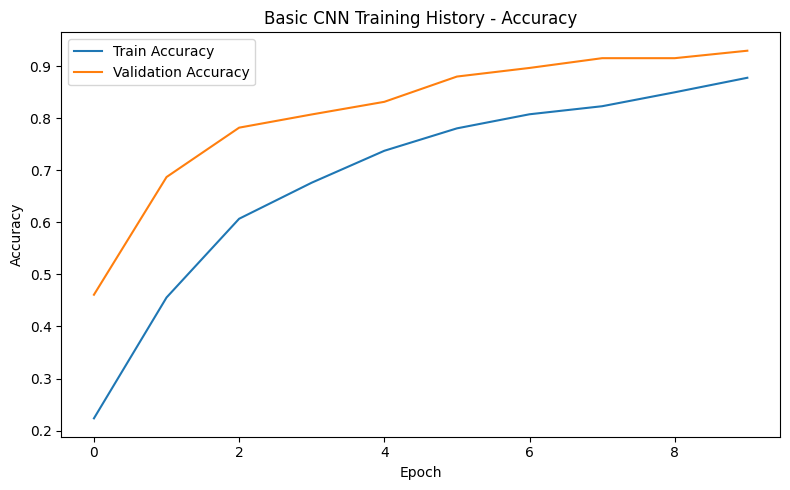

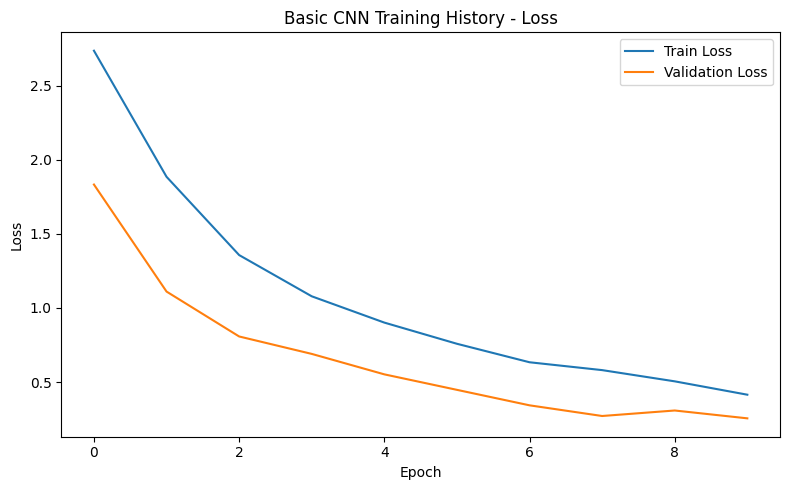

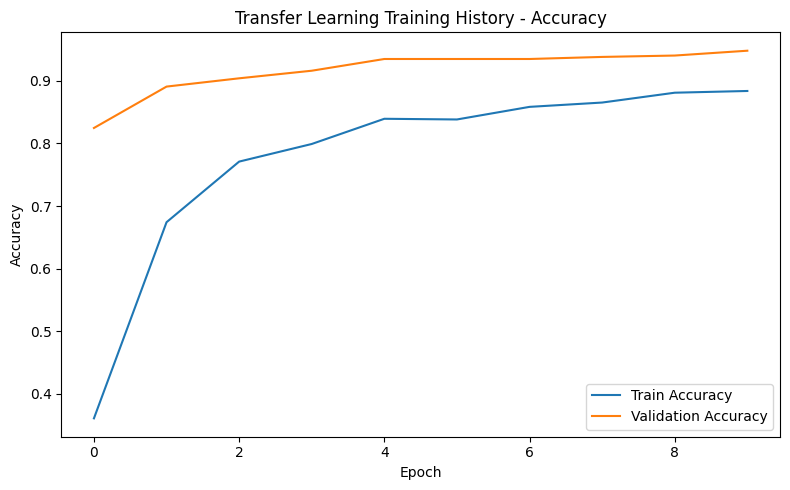

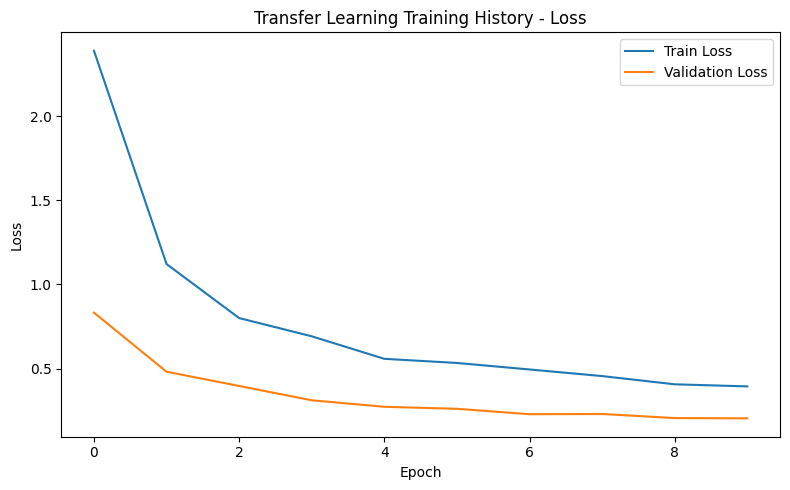

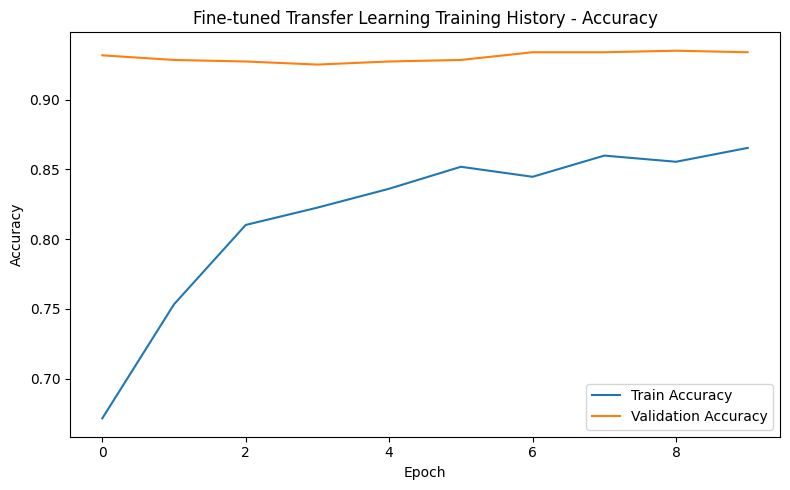

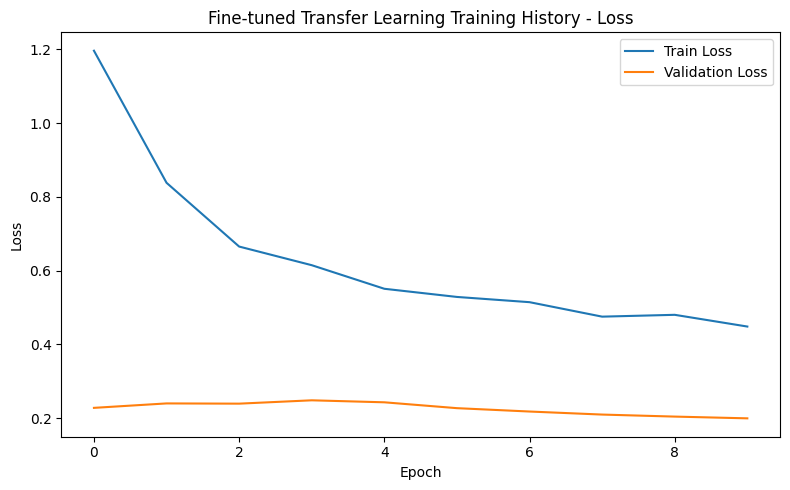

In [ ]:
# Plot accuracy and loss curves for each model to compare training behavior
def plot_training_history(history, title):
    hist_df = pd.DataFrame(history.history)
    
    plt.figure(figsize=(8, 5))
    plt.plot(hist_df["accuracy"], label="Train Accuracy")
    plt.plot(hist_df["val_accuracy"], label="Validation Accuracy")
    plt.title(f"{title} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    plt.figure(figsize=(8, 5))
    plt.plot(hist_df["loss"], label="Train Loss")
    plt.plot(hist_df["val_loss"], label="Validation Loss")
    plt.title(f"{title} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()
    
plot_training_history(history, "Basic CNN Training History")
plot_training_history(history_transfer, "Transfer Learning Training History")
plot_training_history(history_finetune, "Fine-tuned Transfer Learning Training History")

## Compare model performance using validation accuracy

This cell extracts the best validation accuracy achieved by each model and stores the results in a summary table.

In [158]:
# Compare best validation accuracies
base_best = max(history.history["val_accuracy"])
transfer_best = max(history_transfer.history["val_accuracy"])
finetune_best = max(history_finetune.history["val_accuracy"])

results_df = pd.DataFrame({
    "Model": ["Basic CNN", "Transfer Learning", "Fine-tuned Transfer Learning"],
    "Best Validation Accuracy": [base_best, transfer_best, finetune_best]
})

results_df

,Model,Best Validation Accuracy
0,Basic CNN,0.929438
1,Transfer Learning,0.948181
2,Fine-tuned Transfer Learning,0.934950


## Visual comparison of model results

This cell plots the best validation accuracy of each model in a bar chart.

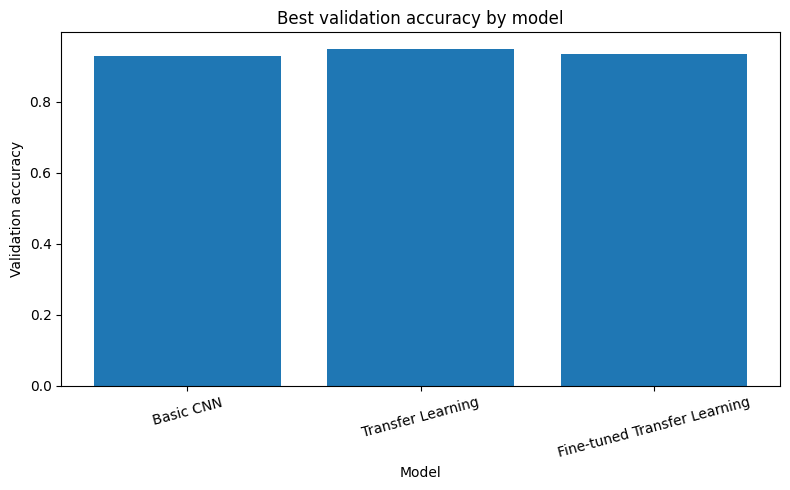

In [ ]:
# Bar chart comparing the best validation accuracy of all trained models
plt.figure(figsize=(8, 5))
plt.bar(results_df["Model"], results_df["Best Validation Accuracy"])
plt.title("Best validation accuracy by model")
plt.xlabel("Model")
plt.ylabel("Validation accuracy")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## Select the final model

This cell identifies the best-performing model based on validation accuracy and records its file path.

In [ ]:
# Select the final model based on the highest validation accuracy
best_model = "Base CNN"
best_model_path = base_model_path
best_score = base_best

if transfer_best > best_score:
    best_model = "Transfer Learning"
    best_model_path = transfer_model_path
    best_score = transfer_best

if finetune_best > best_score:
    best_model = "Fine-tuned Transfer Learning"
    best_model_path = finetune_model_path
    best_score = finetune_best
    
print("Best model:", best_model)
print("Best model path:", best_model_path)
print("Best validation accuracy:", best_score)

Best model: Transfer Learning
Best model path: c:\Users\xriso\Desktop\Project Logo Classification Code\logo_classification_work\models\transfer_learning_best.keras
Best validation accuracy: 0.9481807947158813


## Evaluate the selected model on the validation set

This cell loads the best saved model and evaluates it on the validation data. The reported validation loss and accuracy summarize the performance of the final selected model.

In [ ]:
# Load the selected final model and evaluate it on the validation dataset
final_model = tf.keras.models.load_model(best_model_path)

val_loss, val_acc = final_model.evaluate(val_data)

print("Validation Loss:", round(val_loss, 4))
print("Validation Accuracy:", round(val_acc, 4))

29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 98ms/step - accuracy: 0.9482 - loss: 0.2051 
Validation Loss: 0.2051
Validation Accuracy: 0.9482


## Generate a classification report

This cell computes class predictions on the validation set and prints a classification report. The report includes precision, recall, and F1-score for each logo class.

In [ ]:
# Generate classification report for the validation set
val_probs = final_model.predict(val_data)
val_preds = np.argmax(val_probs, axis=1)
val_true = val_data.classes

idx_to_class = {v: k for k, v in val_data.class_indices.items()}
target_names = [idx_to_class[i] for i in range(len(idx_to_class))]

print("Classification Report:")
print(classification_report(val_true, val_preds, target_names=target_names))

29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 113ms/step
Classification Report:
              precision    recall  f1-score   support

      Adidas       1.00      1.00      1.00        51
       Apple       0.85      0.96      0.90        52
         BMW       1.00      1.00      1.00        24
     Citroen       1.00      0.95      0.98        42
    Cocacola       0.89      1.00      0.94        56
         DHL       1.00      0.92      0.96        24
       Fedex       1.00      0.96      0.98        24
     Ferrari       1.00      1.00      1.00        21
        Ford       1.00      0.92      0.96        26
      Google       1.00      1.00      1.00        23
          HP       1.00      1.00      1.00        22
    Heineken       1.00      0.97      0.98        32
       Intel       1.00      0.84      0.91        25
   McDonalds       1.00      0.80      0.89        25
        Mini       1.00      1.00      1.00        21
         Nbc       1.00      1.00      1.00        21
        Nike     

## Predict labels for the test set

This cell generates predictions on the test/query dataset and stores the filenames, true labels, and predicted labels in a DataFrame.

In [ ]:
# Generate predictions for the test/query set and store them in a DataFrame
test_probs = final_model.predict(test_data)
test_preds = np.argmax(test_probs, axis=1)
test_true = test_data.classes

idx_to_class_test = {v: k for k, v in test_data.class_indices.items()}

predictions_df = pd.DataFrame({
    "filename": [Path(f).name for f in test_data.filenames],
    "true_label": [idx_to_class_test[i] for i in test_true],
    "predicted_label": [idx_to_class_test[i] for i in test_preds]
})

predictions_df.head(20)

9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 159ms/step


,filename,true_label,predicted_label
0,2403695909.jpg,Adidas,Adidas
1,2912587920.jpg,Adidas,Nike
2,3441398196.jpg,Adidas,Heineken
3,4605630935.jpg,Adidas,Mini
4,4606245138.jpg,Adidas,Ferrari
5,161270014.jpg,Apple,Apple
6,3276332721.jpg,Apple,Apple
7,3842830049.jpg,Apple,Apple
8,4748791597.jpg,Apple,Apple
9,51409302.jpg,Apple,Apple


## Save predictions and final model

This cell saves the test predictions to a CSV file and saves the final selected model.

In [164]:
# Save predictions to CSV
predictions_csv_file = work_dir / "test_predictions.csv"
predictions_df.to_csv(predictions_csv_file, index=False)
print("Test predictions saved to:", predictions_csv_file)

# Save the final model
final_saved_model_path = model_dir / "final_logo_classifier.keras"
final_model.save(final_saved_model_path)
print("Final model saved to:", final_saved_model_path)

Test predictions saved to: c:\Users\xriso\Desktop\Project Logo Classification Code\logo_classification_work\test_predictions.csv
Final model saved to: c:\Users\xriso\Desktop\Project Logo Classification Code\logo_classification_work\models\final_logo_classifier.keras


## Reload the final model and apply it to the test set

It loads the saved final model from disk, prepares the test data again, applies the model to the test images and outputs a prediction table.

In [ ]:
final_model_path = Path("logo_classification_work/models/final_logo_classifier.keras")
test_dir = Path("logo_classification_work/dataset/test")

loaded_model = tf.keras.models.load_model(final_model_path)

test_gen = ImageDataGenerator(rescale=1./255)

loaded_test_data = test_gen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode=None,
    shuffle=False
)

pred_probs = loaded_model.predict(loaded_test_data, verbose=1)
preds = np.argmax(pred_probs, axis=1)

idx_to_class = {v: k for k, v in train_data.class_indices.items()}

submission_df = pd.DataFrame({
    "filename": [Path(f).name for f in loaded_test_data.filenames],
    "predicted_label": [idx_to_class[i] for i in preds]
})

print(submission_df.head(20))

Found 270 images belonging to 28 classes.
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 139ms/step
          filename predicted_label
0   2403695909.jpg          Adidas
1   2912587920.jpg            Nike
2   3441398196.jpg        Heineken
3   4605630935.jpg            Mini
4   4606245138.jpg         Ferrari
5    161270014.jpg           Apple
6   3276332721.jpg           Apple
7   3842830049.jpg           Apple
8   4748791597.jpg           Apple
9     51409302.jpg           Apple
10  2802471529.jpg             BMW
11  3159686523.jpg             BMW
12  3744679341.jpg         Citroen
13   388978947.jpg           Pepsi
14   401253895.jpg            Mini
15  2588612032.jpg            Ford
16  2950778947.jpg         Citroen
17  3272258283.jpg         Citroen
18  4735811136.jpg            Nike
19   477690498.jpg        Heineken
